# YOLOv8x Demo: Base vs. Fine-Tuned Pipeline Comparison

This notebook demonstrates the qualitative and quantitative performance difference between the out-of-the-box **YOLOv8x Base Model (Pre-trained on COCO)** and your **Fine-Tuned YOLOv8x Model** (trained on Concentrix Invoice Documents at 1664x1280 resolution with 6-channel warm start).

### Pipeline Breakdown
1. **Shared Setup**: Configuration of workspace paths, model checkpoints, and target validation invoices.
2. **Base Model Inference**: Demonstration of COCO pre-trained `yolov8x.pt` on a sample invoice document.
3. **Fine-Tuned Model Inference**: Inference on sampled validation invoices using `train10/weights/best.pt`.
4. **Evaluation & Visualization**: Rendering detection bounding boxes for KILE header fields and line-item regions.

## Step 0: Shared Setup & Configurations
Import required libraries, verify model weights, and load evaluation invoice images.

In [ ]:
import os
import sys
import json
import random
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
# --- ROBUST PATH RESOLUTION ---
CWD = Path(os.getcwd())
BASE_DIR = CWD.parent if CWD.name.lower() == 'report' else CWD
FINE_TUNING_DIR = BASE_DIR / "Fine-tuning"
EVAL_DIR = BASE_DIR / "Evaluate"
EVAL_IMAGES_DIR = EVAL_DIR / "eval_images"
if not EVAL_IMAGES_DIR.exists() or len(list(EVAL_IMAGES_DIR.glob('*'))) == 0:
    EVAL_IMAGES_DIR = FINE_TUNING_DIR / "processed_data" / "images_source"
# --- CRITICAL: INSERT LOCAL ULTRALYTICS WITH 6-CHANNEL SUPPORT ---
if str(FINE_TUNING_DIR) not in sys.path:
    sys.path.insert(0, str(FINE_TUNING_DIR))
try:
    from ultralytics import YOLO
    print("Ultralytics (6-channel modified) loaded successfully.")
except Exception as e:
    print(f"Error loading ultralytics: {e}")
# Model Checkpoints
# Base model: Docile pre-trained intermediate checkpoint (used for comparison)
BASE_MODEL_PATH = FINE_TUNING_DIR / "train10" / "weights" / "best.pt"
# Fine-tuned model: Concentrix invoice fine-tuned model
FINETUNED_MODEL_PATH = BASE_DIR / "concentrix_finetune" / "weights" / "best.pt"
if not FINETUNED_MODEL_PATH.exists():
    FINETUNED_MODEL_PATH = FINE_TUNING_DIR / "train10" / "weights" / "best.pt"
# Verification
print(f"Base Directory: {BASE_DIR}")
print(f"Base Model Path (train10/{BASE_MODEL_PATH.name}): {BASE_MODEL_PATH.exists()}")
print(f"Fine-Tuned Model Path (concentrix_finetune/{FINETUNED_MODEL_PATH.name}): {FINETUNED_MODEL_PATH.exists()}")
print(f"Eval Images Directory ({EVAL_IMAGES_DIR.name}): {EVAL_IMAGES_DIR.exists()}")

Ultralytics (6-channel modified) loaded successfully.
Base Directory: d:\Internship\Invoice Intelligence Document\YOLOv8x
Base Model Path (train10/best.pt): True
Fine-Tuned Model Path (concentrix_finetune/best.pt): True
Eval Images Directory (eval_images): True
Found 43 evaluation document images.


---
## Step 1: Base Model Inference (Pre-trained `yolov8x.pt` on COCO)
Demonstrates the baseline behavior of the generic COCO pre-trained `yolov8x.pt` model on a sample invoice document.

Running Base (Docile pre-trained) YOLOv8x Model on: invoice_CPC000692108.jpg


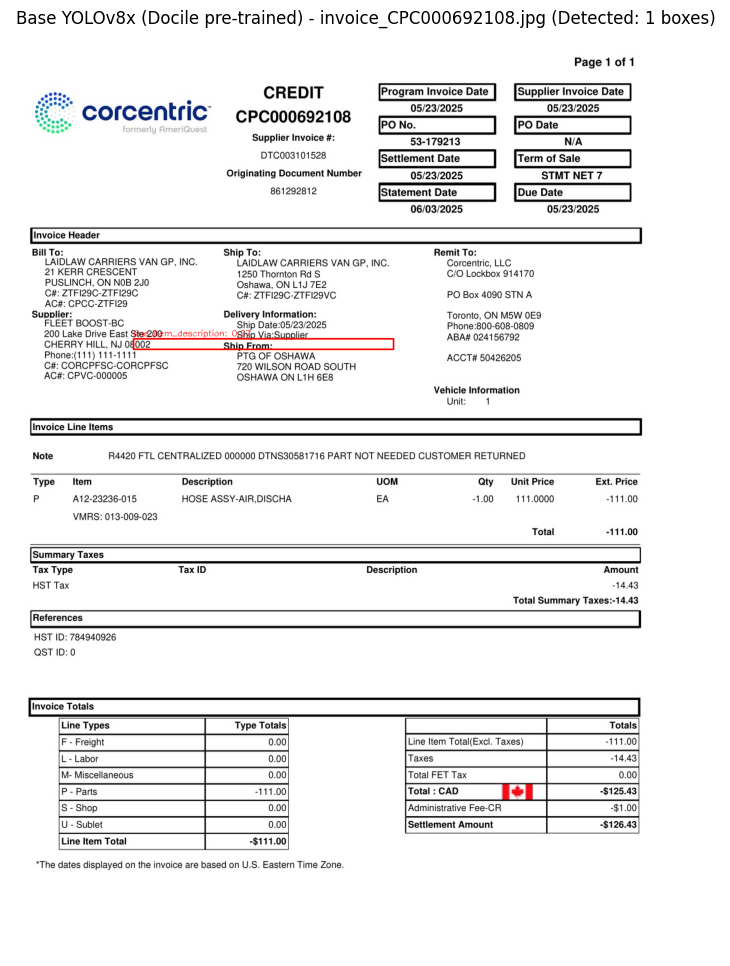

In [ ]:
# Reuse OCR + Chargrid from Step 2 (run Step 2 first, or re-initialize here)
if eval_images:
    sample_img_path = eval_images[0]
    print(f"Running Base (Docile pre-trained) YOLOv8x Model on: {sample_img_path.name}")
    # Load base model (Docile pre-trained, also 6-channel)
    base_model = YOLO(str(BASE_MODEL_PATH))
    img_bgr = cv2.imread(str(sample_img_path))
    img_bgr = cv2.resize(img_bgr, (1280, 1664), interpolation=cv2.INTER_LANCZOS4)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    # 1. OCR Extraction
    from paddleocr import PaddleOCR
    if 'ocr' not in dir():
        ocr = PaddleOCR(use_angle_cls=True, lang='en', show_log=False)
    if 'encs' not in dir():
        encs = create_encodings(characters)
    ocr_res = ocr.ocr(img_rgb, cls=True)
    ocr_data = []
    if ocr_res and ocr_res[0]:
        for line in ocr_res[0]:
            pts, (txt, score) = line[0], line[1]
            x0, y0 = int(min(p[0] for p in pts)), int(min(p[1] for p in pts))
            x1, y1 = int(max(p[0] for p in pts)), int(max(p[1] for p in pts))
            ocr_data.append([[x0, y0, x1, y1], txt])
    # 2. Build 6-channel stacked input (same as fine-tuned model)
    grid = get_char_grid(ocr_data, (h, w), encs)
    grid = (grid * 255).astype(np.uint8)
    stacked = np.concatenate((grid, img_rgb), axis=2)
    # 3. Predict with Base (Docile pre-trained) model
    results_base = base_model.predict(stacked, imgsz=(1664, 1280), conf=0.25, verbose=False)
    # 4. Render detections
    vis_base = img_bgr.copy()
    for box in results_base[0].boxes:
        b = box.xyxy[0].tolist()
        c = int(box.cls)
        conf = float(box.conf)
        lbl = base_model.names[c]
        cv2.rectangle(vis_base, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), (0, 0, 255), 2)
        cv2.putText(vis_base, f"{lbl}: {conf:.2f}", (int(b[0]), int(b[1])-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
    plt.figure(figsize=(10, 12))
    plt.imshow(cv2.cvtColor(vis_base, cv2.COLOR_BGR2RGB))
    plt.title(f"Base YOLOv8x (Docile pre-trained) - {sample_img_path.name} (Detected: {len(results_base[0].boxes)} boxes)")
    plt.axis("off")
    plt.show()
else:
    print("No evaluation images found.")

---
## Step 2: Fine-Tuned YOLOv8x Model Inference
Demonstrates your domain-adapted fine-tuned YOLOv8x model (`train10/weights/best.pt`) on 5 sampled validation invoices at `1664x1280` high resolution.

Initializing PaddleOCR & Fine-Tuned YOLOv8x Model...
[1/5] Running Fine-Tuned Inference on: invoice_CPI007534930.jpg


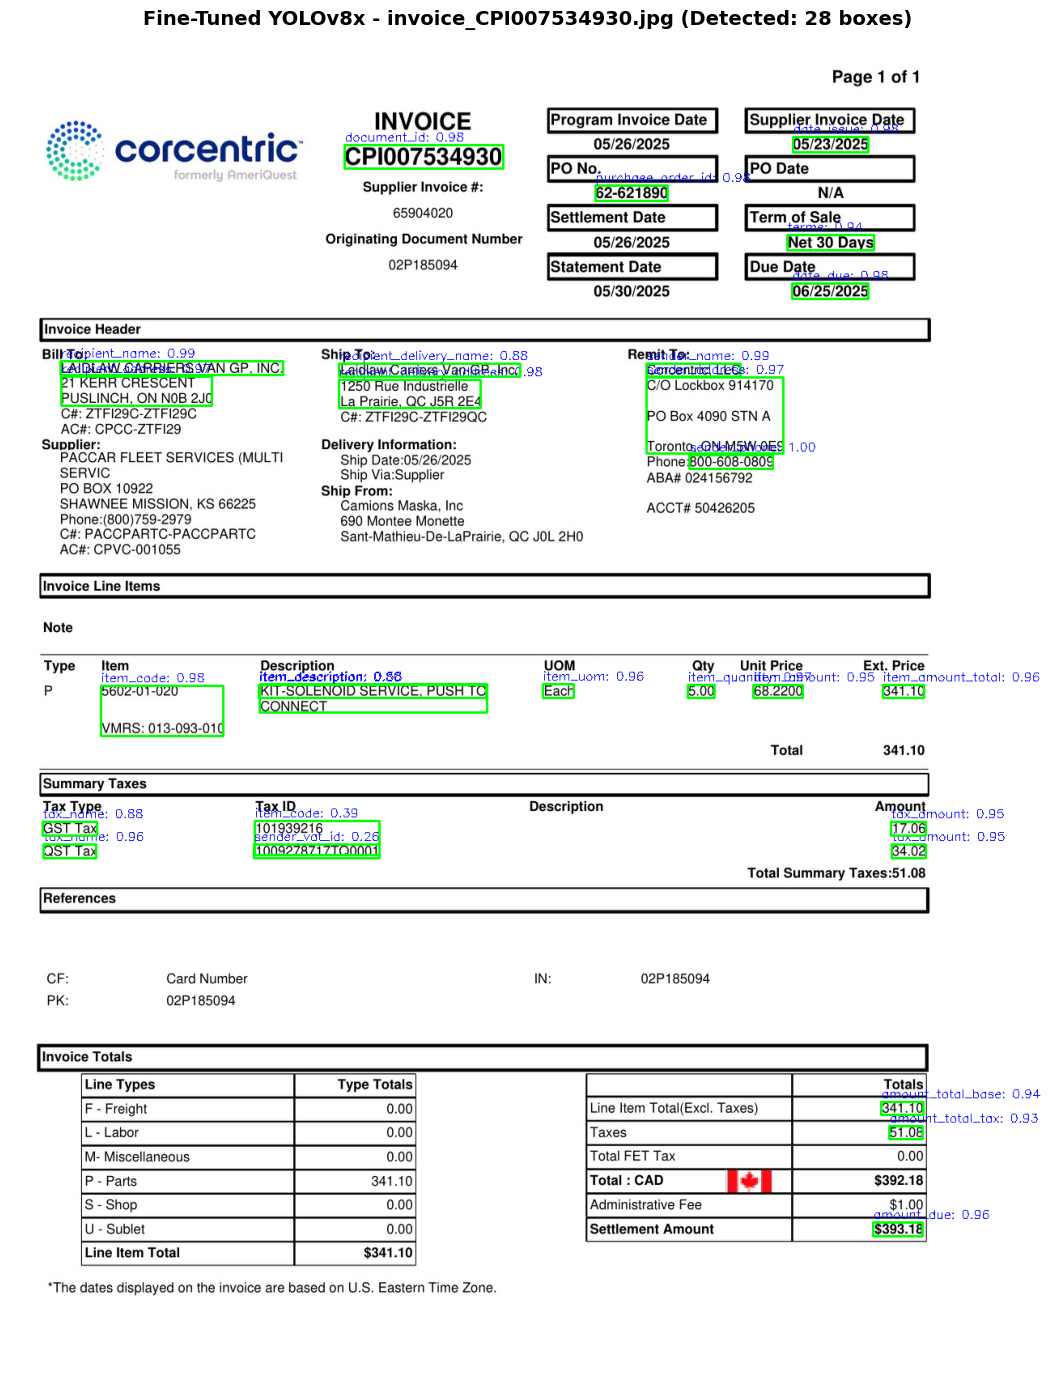

[2/5] Running Fine-Tuned Inference on: invoice_CPI007527454.jpg


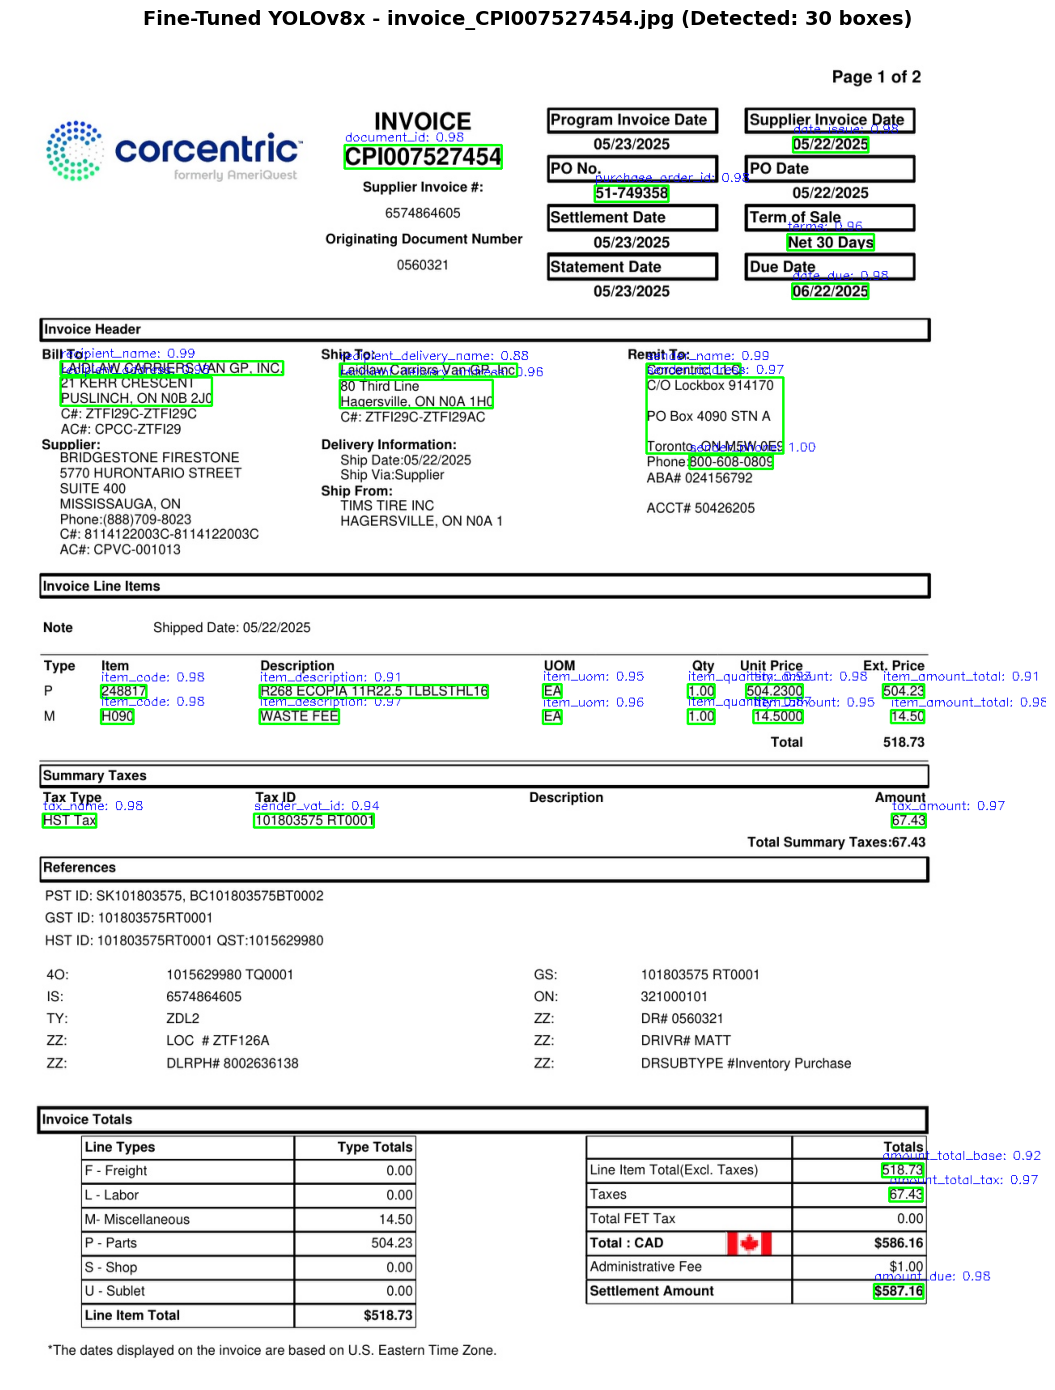

[3/5] Running Fine-Tuned Inference on: invoice_CPC000692500.jpg


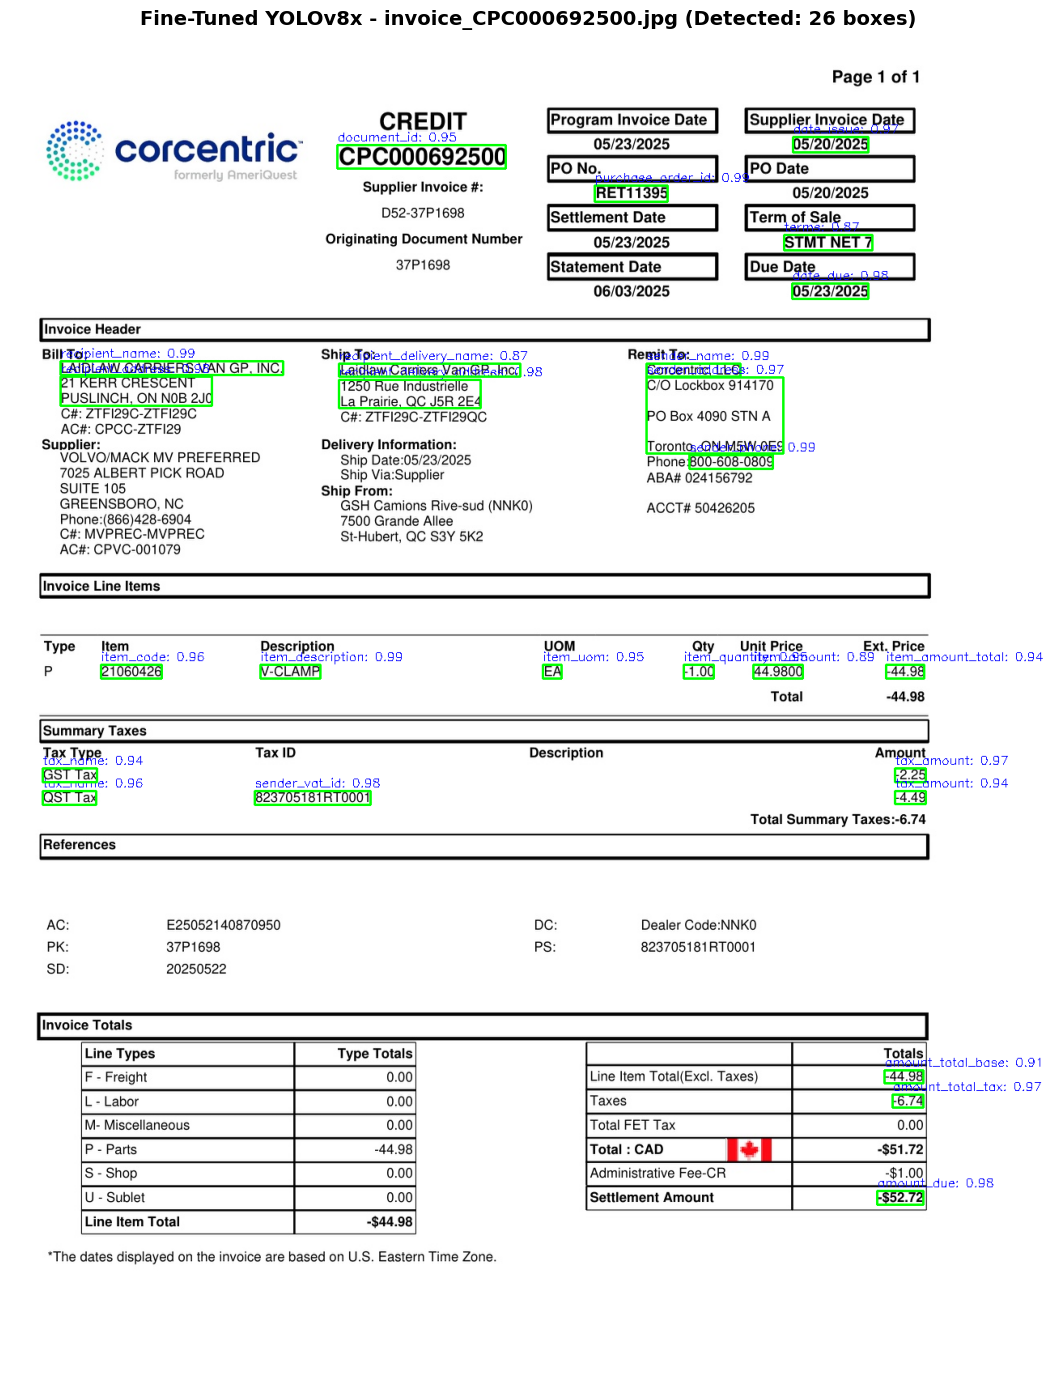

[4/5] Running Fine-Tuned Inference on: invoice_CPI007529687.jpg


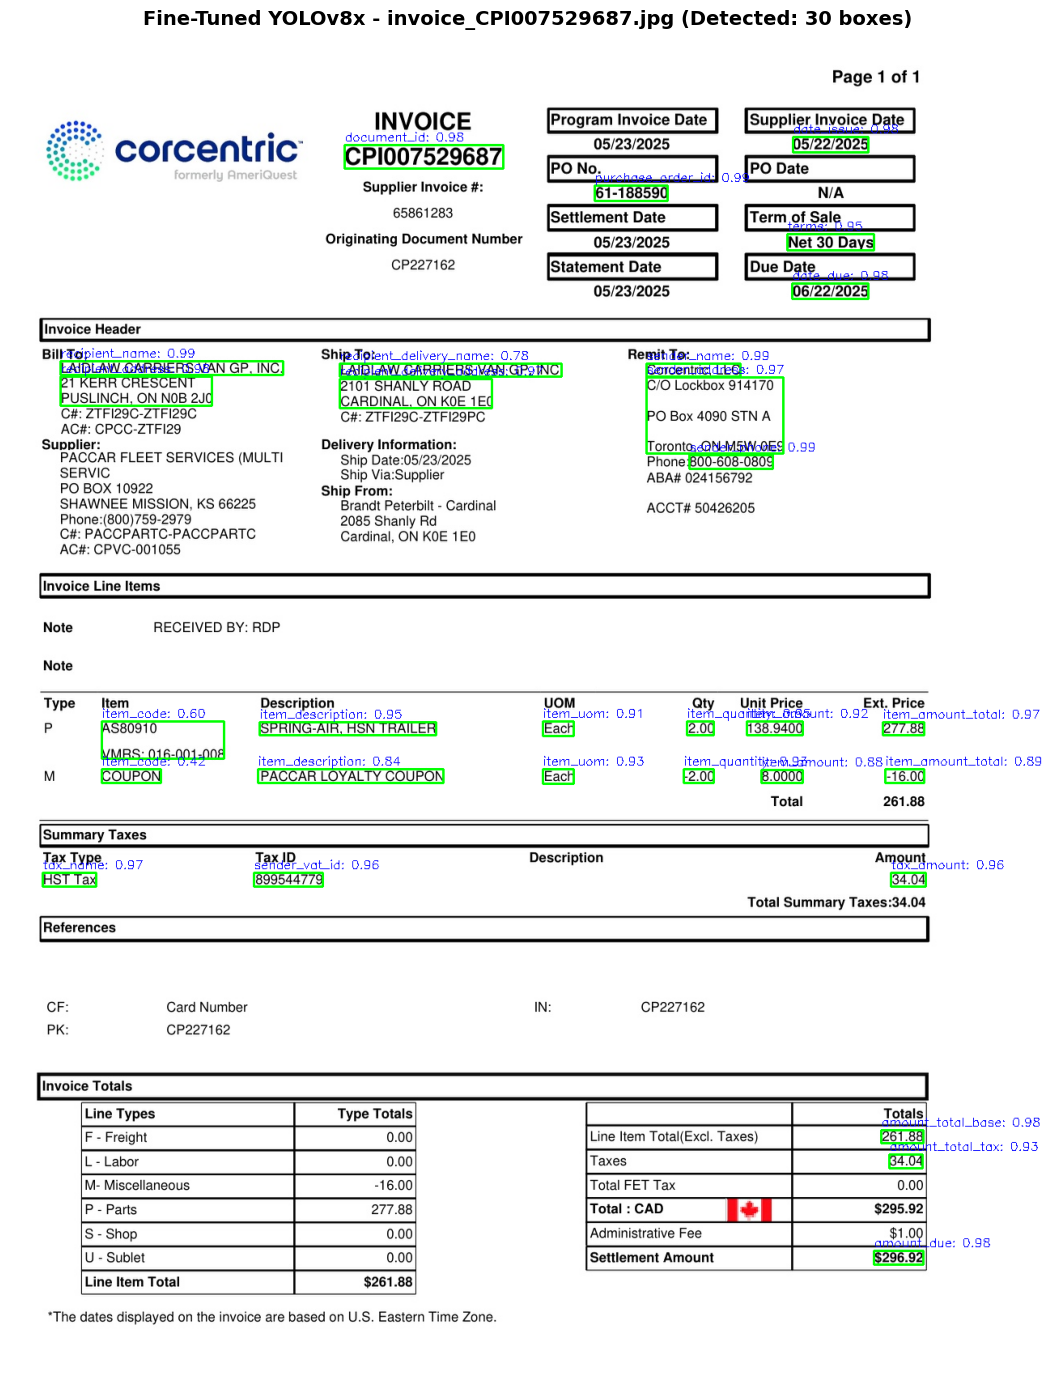

[5/5] Running Fine-Tuned Inference on: invoice_CPI007529644.jpg


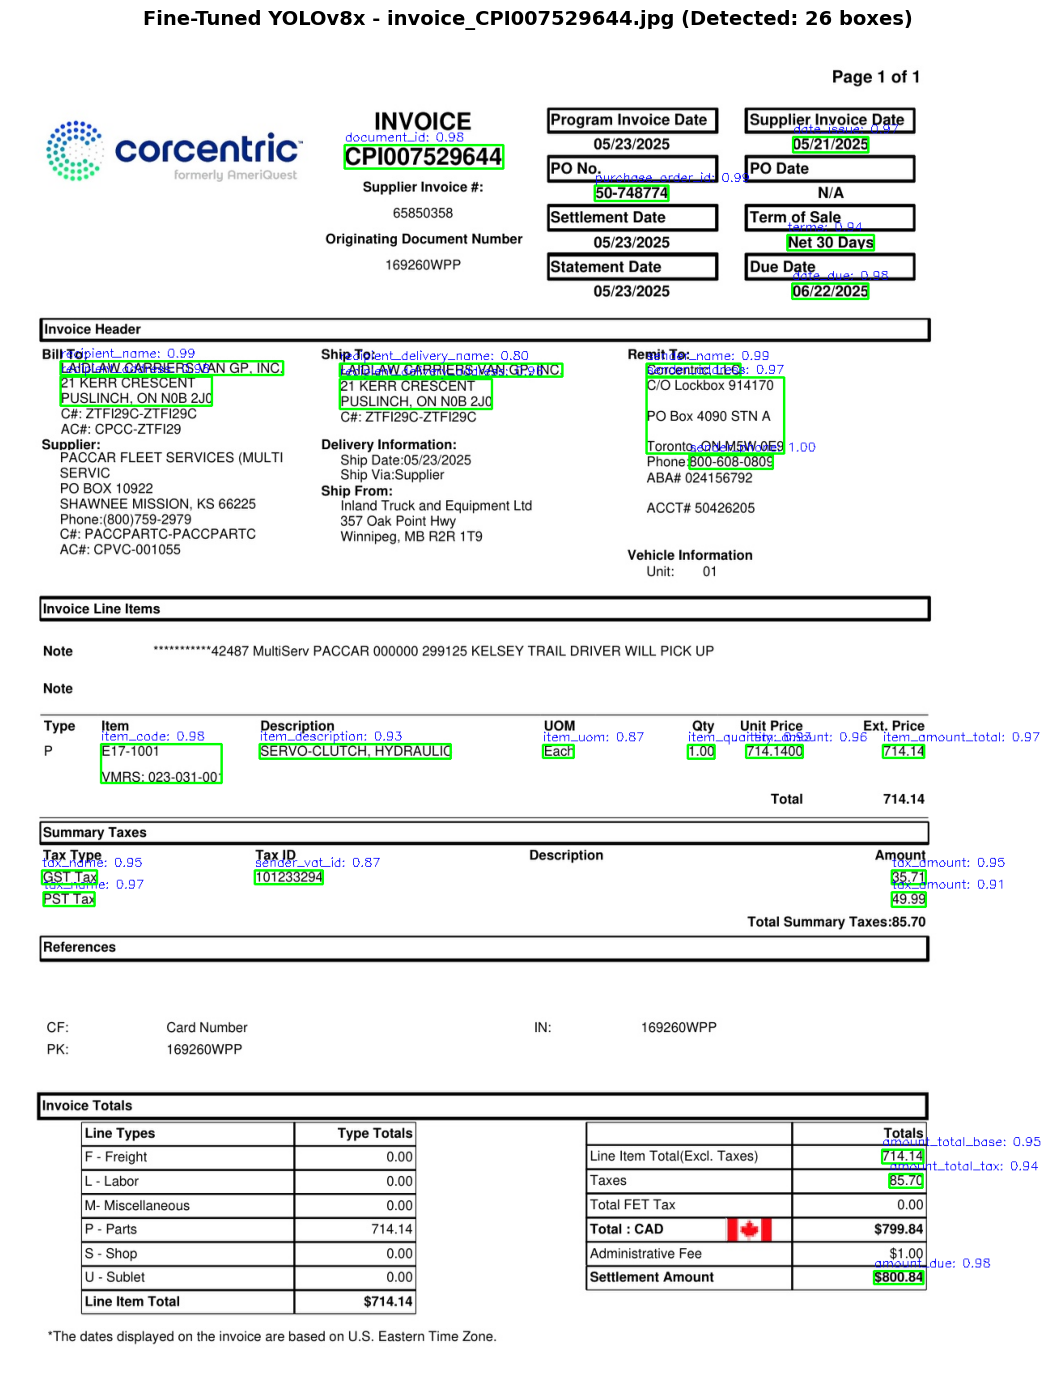

In [10]:
# --- CHARGRID ENCODING HELPERS ---
characters = ['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5',
              '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
              'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '_', 'a', 'b',
              'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w',
              'x', 'y', 'z', '|', '£', '°', 'À', 'Ç', 'È', 'É', 'Ô', 'à', 'â', 'ç', 'è', 'é', 'ê', 'ô', 'û', '€']
def create_encodings(chars):
    chars = ["", *chars]
    base = np.ceil(np.cbrt(len(chars))).astype(int)
    encs = {c: np.base_repr(i, base=base).zfill(3) for i, c in enumerate(chars)}
    encs = {c: np.array([int(v) for v in e]) / (base - 1) for c, e in encs.items()}
    return encs
def get_char_grid(ocr_data, target_size, encs):
    h, w = target_size
    grid = np.zeros((h, w, 3), dtype=np.float32)
    for box, text in ocr_data:
        x0, y0, x1, y1 = box
        for i, char in enumerate(text):
            if char in encs:
                char_w = (x1 - x0) / len(text)
                cx0 = int(x0 + i * char_w)
                cx1 = int(x0 + (i + 1) * char_w)
                grid[y0:y1, cx0:cx1, :] = encs[char]
    return grid
print("Initializing PaddleOCR & Fine-Tuned YOLOv8x Model...")
from paddleocr import PaddleOCR
ocr = PaddleOCR(use_angle_cls=True, lang='en', show_log=False)
encs = create_encodings(characters)
ft_model = YOLO(str(FINETUNED_MODEL_PATH))
# Sample 5 validation images
random.seed(42)
sampled_imgs = random.sample(eval_images, min(5, len(eval_images)))
for idx, img_path in enumerate(sampled_imgs, 1):
    print(f"[{idx}/{len(sampled_imgs)}] Running Fine-Tuned Inference on: {img_path.name}")
    img_bgr = cv2.imread(str(img_path))
    img_bgr = cv2.resize(img_bgr, (1280, 1664), interpolation=cv2.INTER_LANCZOS4)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    # 1. OCR Extraction
    ocr_res = ocr.ocr(img_rgb, cls=True)
    ocr_data = []
    if ocr_res and ocr_res[0]:
        for line in ocr_res[0]:
            pts, (txt, score) = line[0], line[1]
            x0, y0 = int(min(p[0] for p in pts)), int(min(p[1] for p in pts))
            x1, y1 = int(max(p[0] for p in pts)), int(max(p[1] for p in pts))
            ocr_data.append([[x0, y0, x1, y1], txt])
    # 2. Build 3-channel Chargrid map & stack to 6 channels [H, W, 6]
    grid = get_char_grid(ocr_data, (h, w), encs)
    grid = (grid * 255).astype(np.uint8)
    stacked = np.concatenate((grid, img_rgb), axis=2)
    # 3. Predict with Fine-Tuned YOLOv8x
    results_ft = ft_model.predict(stacked, imgsz=(1664, 1280), conf=0.25, verbose=False)
    # 4. Render Detections on invoice image
    vis_img = img_bgr.copy()
    for box in results_ft[0].boxes:
        b = box.xyxy[0].tolist()
        c = int(box.cls)
        conf = float(box.conf)
        lbl = ft_model.names[c]
        cv2.rectangle(vis_img, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), (0, 255, 0), 2)
        cv2.putText(vis_img, f"{lbl}: {conf:.2f}", (int(b[0]), int(b[1])-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    plt.figure(figsize=(12, 14))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Fine-Tuned YOLOv8x - {img_path.name} (Detected: {len(results_ft[0].boxes)} boxes)",
              fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    plt.show()